<a href="https://colab.research.google.com/github/Anupampal1992/Group-Project/blob/Final/Project_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!git clone  https://github.com/Anupampal1992/Group-Project.git
%cd Group-Project
!ls

Cloning into 'Group-Project'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 62 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 234.75 KiB | 4.12 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/Group-Project/Group-Project
 Traffic_Accident.ipynb  'Traffic Accident Severity Predictor Dataset.csv'


In [8]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [9]:
import pandas as pd
import numpy as np
!pip install catboost
from catboost import CatBoostClassifier

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2

#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

#Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from imblearn.over_sampling import SMOTE, SMOTENC

Load the DATA Set

In [10]:
df = pd.read_csv("Traffic Accident Severity Predictor Dataset.csv")
df.head(5)

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1


Data Preprocessing

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               19958 non-null  object 
 1   Road_Type             19958 non-null  object 
 2   Time_of_Day           19958 non-null  object 
 3   Traffic_Density       19958 non-null  float64
 4   Speed_Limit           19958 non-null  float64
 5   Number_of_Vehicles    19958 non-null  float64
 6   Driver_Alcohol        19958 non-null  float64
 7   Accident_Severity     19958 non-null  object 
 8   Road_Condition        19958 non-null  object 
 9   Vehicle_Type          19958 non-null  object 
 10  Driver_Age            19958 non-null  float64
 11  Driver_Experience     19958 non-null  float64
 12  Road_Light_Condition  19958 non-null  object 
 13  Accident              20000 non-null  int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 2.1+ MB


In [12]:
df.isnull().sum()  # Find the null value

,0
Weather,42
Road_Type,42
Time_of_Day,42
Traffic_Density,42
Speed_Limit,42
Number_of_Vehicles,42
Driver_Alcohol,42
Accident_Severity,42
Road_Condition,42
Vehicle_Type,42


Accident_Severity
Low         11862
Moderate     6090
High         2006
Name: count, dtype: int64


<Axes: xlabel='Accident_Severity'>

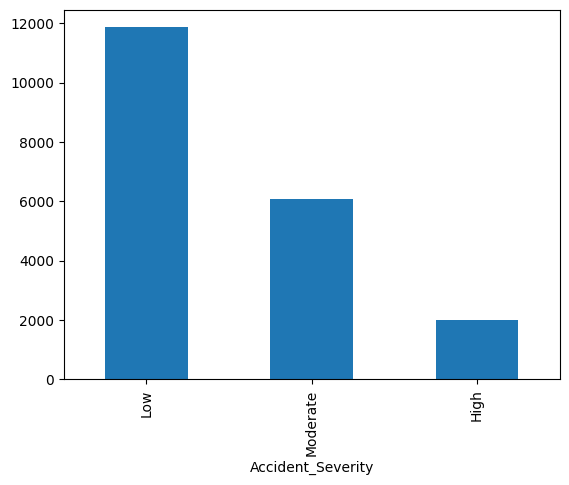

In [13]:
print(df["Accident_Severity"].value_counts()) # Evaluating the Target Column
df["Accident_Severity"].value_counts().plot(kind='bar')


In [14]:
num_col = df.select_dtypes(include=['float64', 'int64']).columns  # Getteing all Numerical Columns together
cat_col = df.select_dtypes(include=["object"]).columns            # Getting all features Columns Together

**Plotting the graph for all Numerical Columns as per our target**\\

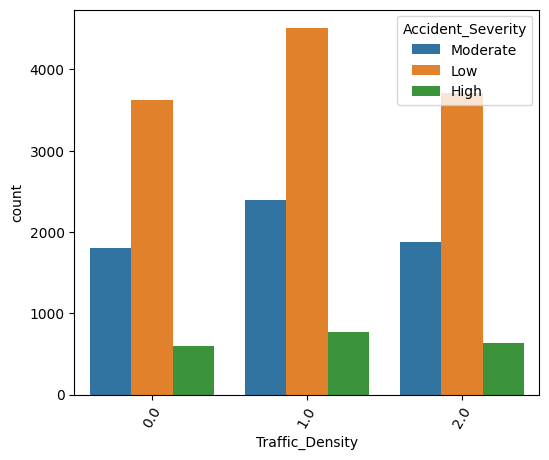

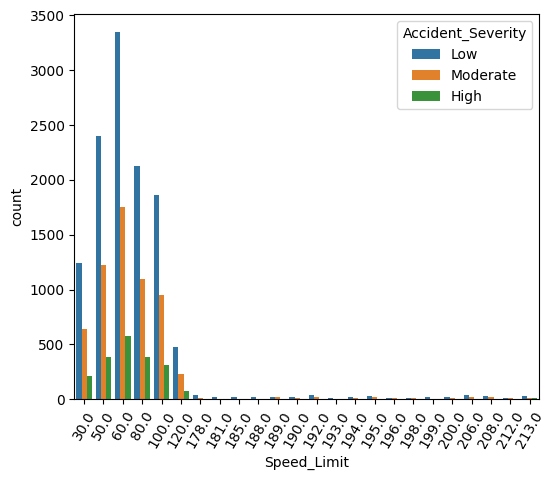

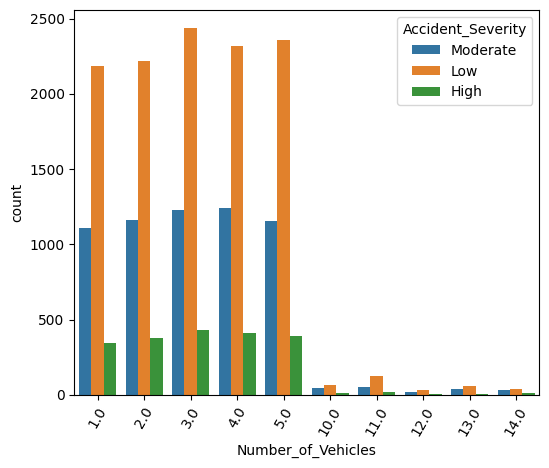

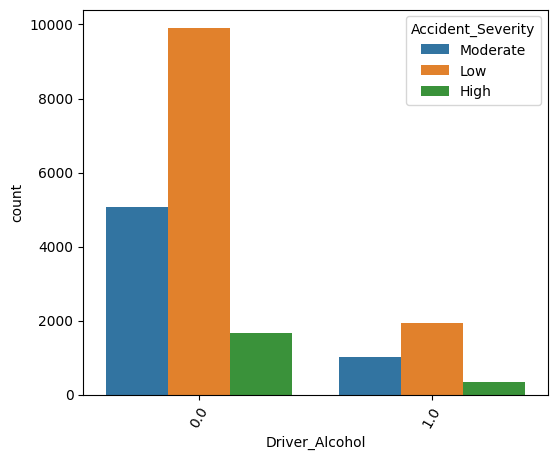

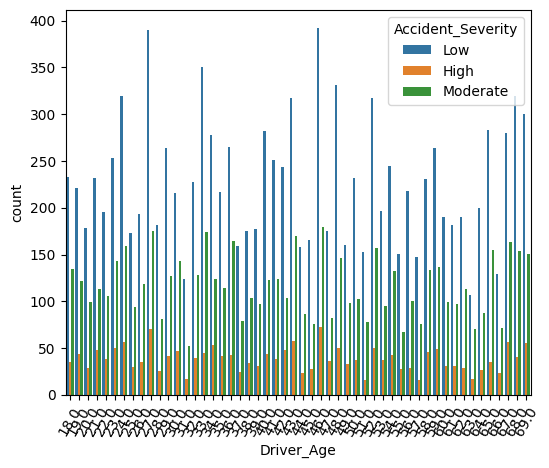

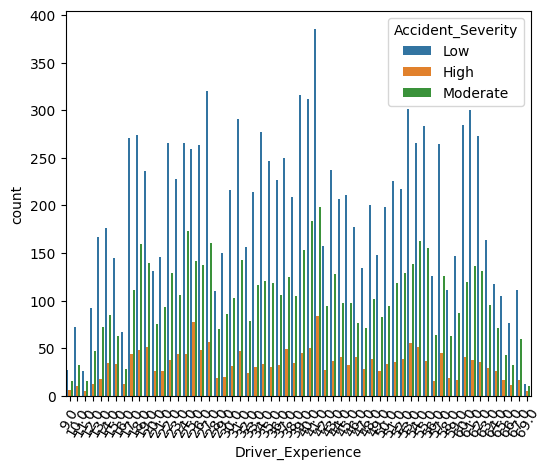

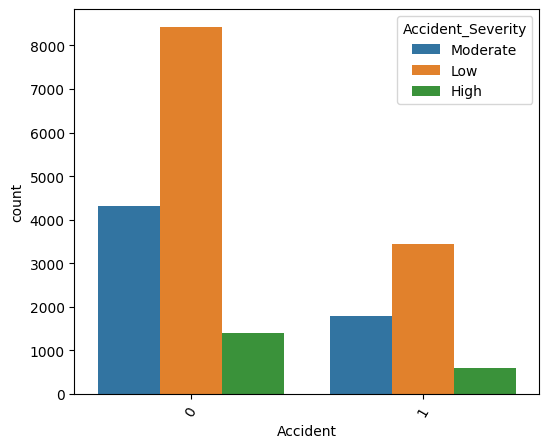

In [15]:
for col in num_col:
  plt.figure(figsize=(6,5))
  sns.countplot(x=col, hue="Accident_Severity", data=df)
  plt.xlabel(col)
  plt.xticks(rotation=60)
  plt.show()

**Plotting the graph for all Categorical Columns as per our target**

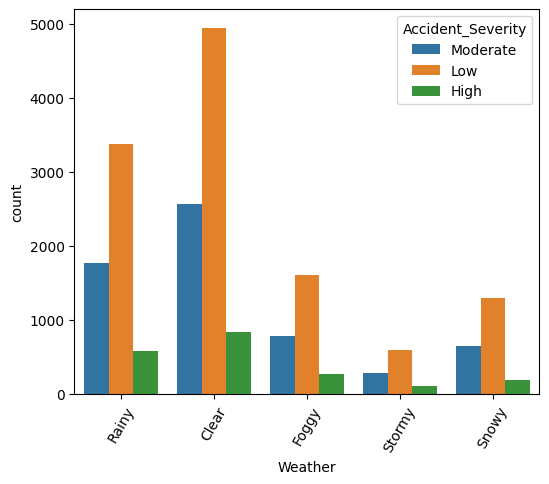

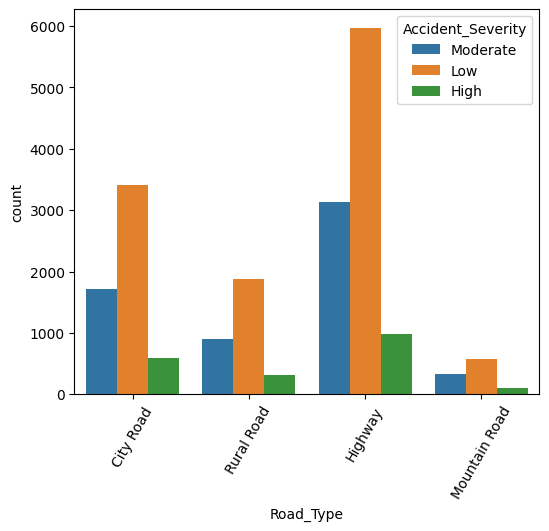

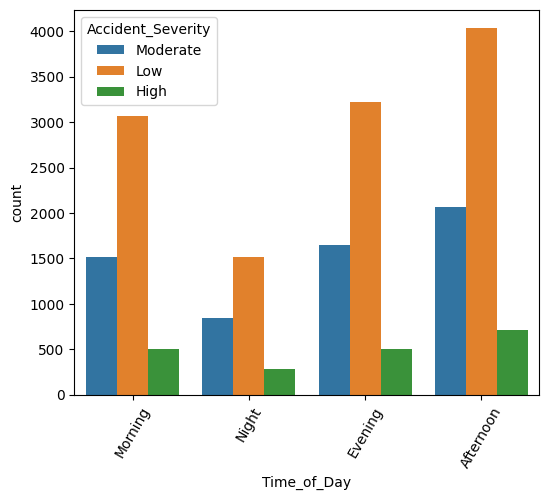

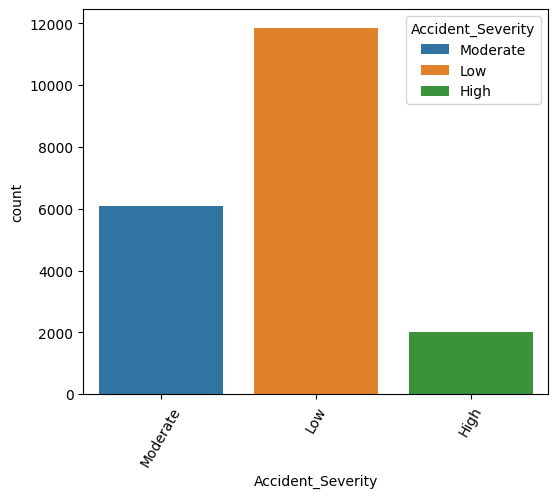

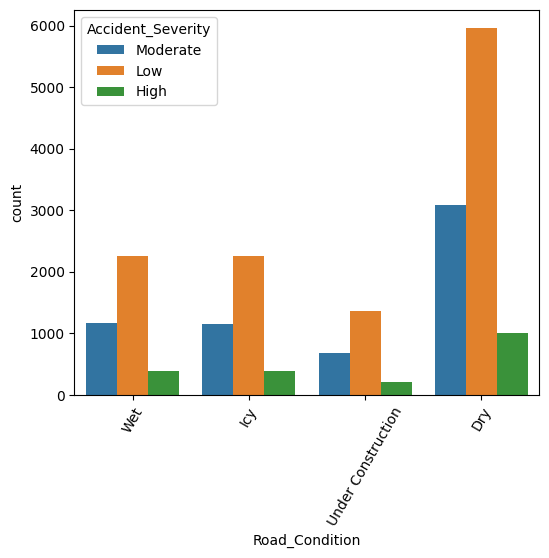

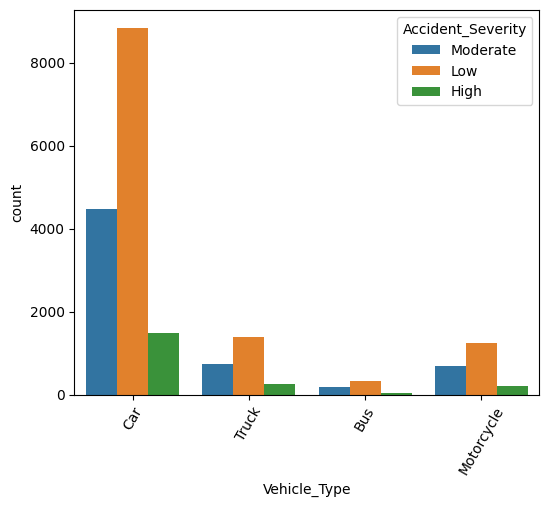

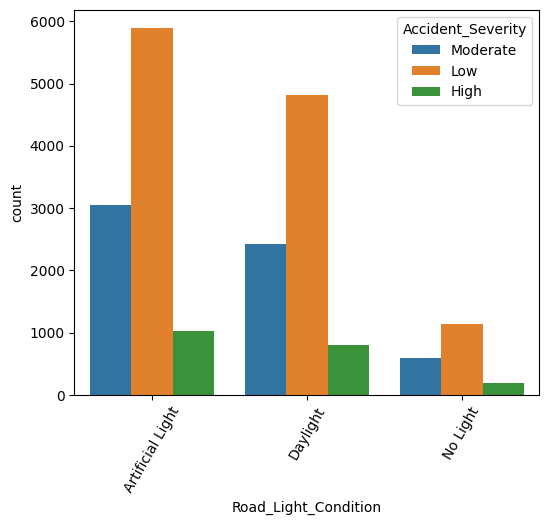

In [16]:
for cat in cat_col:
  plt.figure(figsize=(6,5))
  sns.countplot(x=cat, hue="Accident_Severity", data=df)
  plt.xlabel(cat)
  plt.xticks(rotation=60)
  plt.show()

**Handling the null values**

In [17]:
df[num_col] = df[num_col].fillna(df[num_col].median())
df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])
df.isnull().sum()

,0
Weather,0
Road_Type,0
Time_of_Day,0
Traffic_Density,0
Speed_Limit,0
Number_of_Vehicles,0
Driver_Alcohol,0
Accident_Severity,0
Road_Condition,0
Vehicle_Type,0


In [18]:
df.duplicated().any() #Getting Duplicate value

np.True_

In [19]:

df = df.drop_duplicates() #Dropping the Duplicate values
df.duplicated().sum()

np.int64(0)

In [20]:
X = df.drop('Accident_Severity', axis=1) #dropping Target from rest of Columns
y = df['Accident_Severity']              #Assigning taget to Y
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19982 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               19982 non-null  object 
 1   Road_Type             19982 non-null  object 
 2   Time_of_Day           19982 non-null  object 
 3   Traffic_Density       19982 non-null  float64
 4   Speed_Limit           19982 non-null  float64
 5   Number_of_Vehicles    19982 non-null  float64
 6   Driver_Alcohol        19982 non-null  float64
 7   Road_Condition        19982 non-null  object 
 8   Vehicle_Type          19982 non-null  object 
 9   Driver_Age            19982 non-null  float64
 10  Driver_Experience     19982 non-null  float64
 11  Road_Light_Condition  19982 non-null  object 
 12  Accident              19982 non-null  int64  
dtypes: float64(6), int64(1), object(6)
memory usage: 2.1+ MB


In [21]:
order = {'Low': 0, 'Moderate': 1, 'High': 2}
y_en = y.map(order)
print("Target distribution:")
print(y_en.value_counts().sort_index())

Target distribution:
Accident_Severity
0    11891
1     6086
2     2005
Name: count, dtype: int64


**One-Hot Encode Features**

In [22]:
encoded_df = pd.get_dummies(X,drop_first=True).astype(int)
print(encoded_df.shape)

(19982, 25)


Smote balancing

In [23]:
##le = LabelEncoder()
##le.fit(y)
#y_encoded = le.transform(y)
#print("Encoded labels:", le.classes_)
#y_en = pd.Series(y_encoded)

**Mutual Information (Analysis Only)**

In [24]:
mi_clas = mutual_info_classif(encoded_df, y_en, random_state=42)

In [25]:
mi_df = pd.DataFrame({'columns':encoded_df.columns, "Mi_Score":mi_clas})
mi_df.sort_values(by="Mi_Score", ascending=False).head(15)

,columns,Mi_Score
18,Road_Condition_Under Construction,0.004848
9,Weather_Snowy,0.004200
23,Road_Light_Condition_Daylight,0.002883
15,Time_of_Day_Morning,0.002078
13,Road_Type_Rural Road,0.002037
10,Weather_Stormy,0.002019
0,Traffic_Density,0.001644
14,Time_of_Day_Evening,0.001643
20,Vehicle_Type_Car,0.001487
1,Speed_Limit,0.001396


**Feature Selection (Chi-Square)**

In [26]:
fs = SelectKBest(score_func=chi2,k=50)
X_new = fs.fit_transform(encoded_df,y_en)
selected_cols = fs.get_feature_names_out()

#X_new.shape
#cols = fs.get_feature_names_out()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=50 is greater than n_features=25. All the features will be returned.
  warnings.warn(


In [27]:
fs_df = pd.DataFrame(X_new, columns=selected_cols)
print(fs_df.shape)

(19982, 25)


In [31]:
n_cat_index = list(range(7, len(fs_df.columns))) # Corrected range for categorical features

smote = SMOTENC(categorical_features = n_cat_index, random_state = 42)
X_n,y_n = smote.fit_resample(fs_df,y_en)
X_n.shape, y_n.shape

((35673, 25), (35673,))

In [32]:
X_trn, X_tst, y_trn, y_tst = train_test_split(X_n, y_n, test_size=0.2, stratify=y_n, random_state=42)


Randorm Forest

In [33]:
rf = RandomForestClassifier(n_estimators=300,
    max_depth=10,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
rf.fit(X_trn, y_trn)
predicts = rf.predict(X_tst)

In [34]:
print(rf.score(X_trn, y_trn))
print(rf.score(X_tst, y_tst))

0.5594295325530871
0.548563419761738


In [35]:
classif_re = classification_report(y_tst,predicts)
print("RF1 Score", rf.score(X_trn, y_trn))
print("Acuracy report", accuracy_score(y_tst, predicts))
print(classif_re)

RF1 Score 0.5594295325530871
Acuracy report 0.548563419761738
              precision    recall  f1-score   support

           0       0.56      0.80      0.66      2378
           1       0.49      0.07      0.12      2378
           2       0.55      0.78      0.64      2379

    accuracy                           0.55      7135
   macro avg       0.53      0.55      0.47      7135
weighted avg       0.53      0.55      0.47      7135



In [36]:
#Decision tree

d_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, min_samples_split=40, class_weight="balanced", random_state=42)
d_tree.fit(X_trn, y_trn)
predict_dt = d_tree.predict(X_tst)
score_d_tree = d_tree.score(X_tst, y_tst)
print("Model Accuracy:", score_d_tree)
print("Trane score:",d_tree.score(X_trn, y_trn))
print("Test score:",d_tree.score(X_tst, y_tst))

Model Accuracy: 0.4905395935529082
Trane score: 0.5092858644614199
Test score: 0.4905395935529082


In [37]:
classif_report_DT = classification_report(y_tst,predict_dt)
print(classif_report_DT)

              precision    recall  f1-score   support

           0       0.53      0.64      0.58      2378
           1       0.33      0.03      0.06      2378
           2       0.47      0.80      0.59      2379

    accuracy                           0.49      7135
   macro avg       0.45      0.49      0.41      7135
weighted avg       0.45      0.49      0.41      7135



In [38]:
param_grid = {
    "max_depth": [5, 7, 9, 12],
    "min_samples_leaf": [10, 20, 30],
    "min_samples_split": [20, 40, 60]
}

grid = GridSearchCV(
    DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid,
    scoring="f1_macro",
    cv=5
)

grid.fit(X_trn, y_trn)

best_dt = grid.best_estimator_

In [39]:
print("Trane score:",best_dt.score(X_trn, y_trn))
print("Test score:",best_dt.score(X_tst, y_tst))

y_pred = best_dt.predict(X_tst)
print("confusion matrix:", confusion_matrix(y_tst, y_pred))
print(classification_report(y_tst, y_pred))
print("Accuracy:", accuracy_score(y_tst,y_pred))

Trane score: 0.5583082206181232
Test score: 0.4972669936930624
confusion matrix: [[1394  460  524]
 [ 817  330 1231]
 [ 366  189 1824]]
              precision    recall  f1-score   support

           0       0.54      0.59      0.56      2378
           1       0.34      0.14      0.20      2378
           2       0.51      0.77      0.61      2379

    accuracy                           0.50      7135
   macro avg       0.46      0.50      0.46      7135
weighted avg       0.46      0.50      0.46      7135

Accuracy: 0.4972669936930624


In [40]:
scaler = StandardScaler()
X_trn_scaled = scaler.fit_transform(X_trn)
X_tst_scaled = scaler.transform(X_tst)

knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",   # better for overlap
    metric="minkowski"
)

knn.fit(X_trn_scaled, y_trn)

y_pred = knn.predict(X_tst_scaled)

print("Trane score:",knn.score(X_trn_scaled, y_trn))
print("Test score:",knn.score(X_tst_scaled, y_tst))
print("Accuracy:", accuracy_score(y_tst, y_pred))
print(classification_report(y_tst, y_pred))

Trane score: 0.9992290980447123
Test score: 0.6088297126839524
Accuracy: 0.6088297126839524
              precision    recall  f1-score   support

           0       0.58      0.65      0.61      2378
           1       0.56      0.38      0.45      2378
           2       0.67      0.80      0.73      2379

    accuracy                           0.61      7135
   macro avg       0.60      0.61      0.60      7135
weighted avg       0.60      0.61      0.60      7135



In [41]:
sample_weight = y_trn.map({0:1.0, 1:1.2, 2:1.0})

param_grid = {
    "max_depth": [5, 6],
    "learning_rate": [0.05],
    "n_estimators": [150, 200],
    "subsample": [0.8],
}

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

grid.fit(X_trn, y_trn, sample_weight=sample_weight)

best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_tst)

print("confusion matrix:", confusion_matrix(y_tst, y_pred))
print("Train score:", best_xgb.score(X_trn, y_trn))
print("Test score :", best_xgb.score(X_tst, y_tst))
print("Accuracy   :", accuracy_score(y_tst, y_pred))
print(classification_report(y_tst, y_pred))

confusion matrix: [[1511  688  179]
 [ 752  934  692]
 [ 276  343 1760]]
Train score: 0.6640969934823744
Test score : 0.5893482831114225
Accuracy   : 0.5893482831114225
              precision    recall  f1-score   support

           0       0.60      0.64      0.61      2378
           1       0.48      0.39      0.43      2378
           2       0.67      0.74      0.70      2379

    accuracy                           0.59      7135
   macro avg       0.58      0.59      0.58      7135
weighted avg       0.58      0.59      0.58      7135



In [42]:
importance = best_xgb.feature_importances_  #get the features importance value

#create Dataframe

feat_imp = pd.DataFrame({
    "Feature": encoded_df.columns,
    "Importance": importance
})

#sort by importance

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

#Display top 15
feat_imp.head(30)

,Feature,Importance
18,Road_Condition_Under Construction,0.069077
21,Vehicle_Type_Motorcycle,0.061597
17,Road_Condition_Icy,0.060729
16,Time_of_Day_Night,0.057636
6,Accident,0.055587
9,Weather_Snowy,0.055353
7,Weather_Foggy,0.052588
10,Weather_Stormy,0.050186
14,Time_of_Day_Evening,0.050186
19,Road_Condition_Wet,0.047361


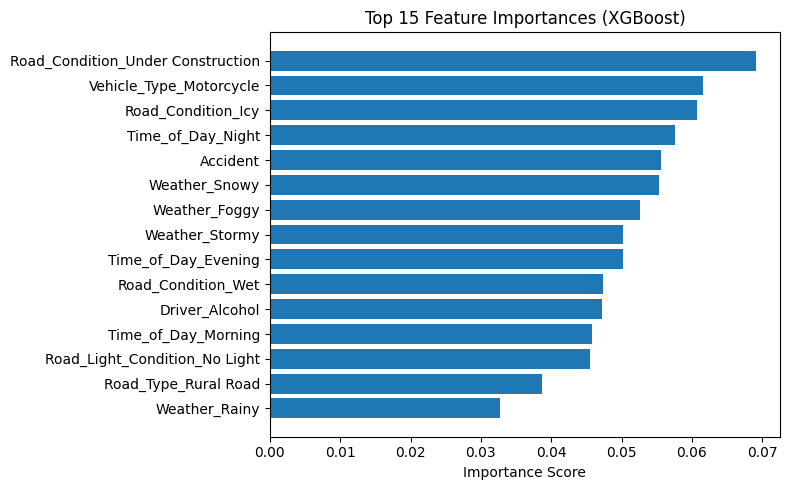

In [43]:
plt.figure(figsize=(8,5))
plt.barh(
    feat_imp.head(15)["Feature"],
    feat_imp.head(15)["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

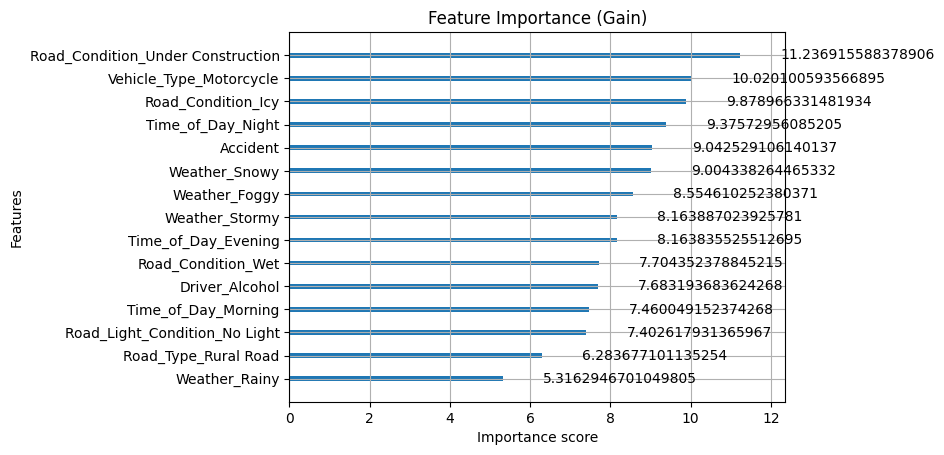

In [44]:
from xgboost import plot_importance

plot_importance(
    best_xgb,
    max_num_features=15,
    importance_type="gain"
)
plt.title("Feature Importance (Gain)")
plt.show()